# Assignment submitted by Heramba Kakati,Batch 13

## Assignment -1 Student Social Network Profile Clustering and Anime Recommendations 

### a)	Explain the Eigenvalue and eigenvector in detail along with some examples. Its role in PCA.

**Eigenvalues and Eigenvectors with their Role in PCA**

**1. Introduction**

In real-world machine learning problems, we often deal with high-dimensional data. Handling such data can be complex and computationally expensive. To simplify this, we use mathematical concepts like eigenvalues and eigenvectors. These concepts are fundamental to Principal Component Analysis (PCA), a technique used to reduce dimensions while retaining important information.

**2. Eigenvalues and Eigenvectors: Definition**

For a square matrix A, if there exists a vector v such that:

Av=λv

Then:

- v is called an eigenvector
- λ is called an eigenvalue

When a transformation (matrix A) is applied:

- Most vectors change both direction and magnitude
- But eigenvectors do not change direction
- They only get scaled (stretched or compressed)

**3. Intuition Behind the Concept**
- Eigenvectors → Direction of data
- Eigenvalues → Importance (or strength) of that direction

In simple terms:
- Eigenvectors tell us where the data is pointing, and eigenvalues tell us how important that direction is.

**4. Simple Example**

Consider the matrix:

$$
A =
\begin{bmatrix}
2 & 0 \\
0 & 3
\end{bmatrix}
$$

If we apply transformation:

For vector $v_1 = [1, 0]$

$$
\begin{aligned}
A
\begin{bmatrix}
1 \\
0
\end{bmatrix}
&=
\begin{bmatrix}
2 & 0 \\
0 & 3
\end{bmatrix}
\begin{bmatrix}
1 \\
0
\end{bmatrix} \\
&=
\begin{bmatrix}
2 \\
0
\end{bmatrix}
= 2
\begin{bmatrix}
1 \\
0
\end{bmatrix}
\end{aligned}
$$



For vector $v_2 = [0, 1]$

$$
\begin{aligned}
A
\begin{bmatrix}
0 \\
1
\end{bmatrix}
&=
\begin{bmatrix}
2 & 0 \\
0 & 3
\end{bmatrix}
\begin{bmatrix}
0 \\
1
\end{bmatrix} \\
&=
\begin{bmatrix}
0 \\
3
\end{bmatrix}
= 3
\begin{bmatrix}
0 \\
1
\end{bmatrix}
\end{aligned}
$$

**Therefore:**

Eigenvectors: [1,0], [0,1]
Eigenvalues: 2 and 3

**Interpretation:**
The second direction is more important because it has a larger eigenvalue (more stretching).

**5. Geometric Understanding**
- Data points are projected onto a direction (eigenvector)
- The best direction is the one that captures maximum spread (variance)

So:

- Eigenvectors define new axes (directions)
- Eigenvalues measure variance along those axes

**6. Role of Eigenvalues and Eigenvectors in PCA**

PCA uses eigenvalues and eigenvectors to reduce the number of features while keeping the most important information.

Steps in PCA

Step 1: Data Standardization

- Data is scaled so that all features contribute equally

Step 2: Covariance Matrix

- Shows relationships between variables

Step 3: Compute Eigenvalues and Eigenvectors

- Extracted from the covariance matrix
- Eigenvectors → directions
- Eigenvalues → importance

Step 4: Form Principal Components

- Eigenvectors become Principal Components (PCs)
- Eigenvalues indicate how much variance each PC explains

**Key Observations**

- First Principal Component (PC1)

  → Has the highest eigenvalue

  → Captures maximum variance

- Second Principal Component (PC2)

  → Second highest eigenvalue

  → Orthogonal (independent) to PC1

**7. Why Eigenvalues are Important in PCA**

Eigenvalues help us decide how many components to keep.

| Component | Eigenvalue | Variance Explained |
| --------- | ---------- | ------------------ |
| PC1       | High       | Maximum            |
| PC2       | Medium     | Moderate           |
| PC3       | Low        | Less               |


**Usually:**

- Keep components with high eigenvalues
- Remove components with low eigenvalues

**8. Conclusion**

Eigenvalues and eigenvectors provide a mathematical way to identify the most important patterns in data. In PCA, they transform the original data into a new coordinate system where maximum variance is captured using fewer dimensions. This makes the data easier to analyze, visualize, and use in machine learning models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

In [2]:
df = pd.read_csv("03_Clustering_Marketing.csv", encoding='utf-8')

In [3]:
df.head(10)

,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2007,NaN,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2007,F,17.41,49,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,2007,F,17.511,41,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1
3,2006,F,NaN,36,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2008,F,16.657,1,0,0,0,0,0,1,...,0,0,0,3,0,0,0,0,0,0
5,2008,M,18.034,32,0,5,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,2006,M,18.53,18,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
7,2006,F,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,2006,F,19.168,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
9,2007,NaN,NaN,21,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0


In [4]:
df.describe(include='all')

,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
count,15000.000000,13663,12504,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,...,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
unique,NaN,2,1906,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,F,16. Jun,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,11057,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2007.496933,NaN,NaN,29.834533,0.267000,0.255467,0.22200,0.159667,0.142933,0.135000,...,0.112867,0.259467,0.357267,0.150267,0.071800,0.051467,0.185867,0.118067,0.091733,0.061067
std,1.116516,NaN,NaN,35.386649,0.788851,0.702260,0.92042,0.737344,0.638747,0.548691,...,2.708619,0.704398,0.728512,0.478716,0.356258,0.280755,0.609928,0.455200,0.420631,0.349112
min,2006.000000,NaN,NaN,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2006.000000,NaN,NaN,3.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2008.000000,NaN,NaN,20.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2008.000000,NaN,NaN,44.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 40 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   gradyear         15000 non-null  int64 
 1   gender           13663 non-null  object
 2   age              12504 non-null  object
 3   NumberOffriends  15000 non-null  int64 
 4   basketball       15000 non-null  int64 
 5   football         15000 non-null  int64 
 6   soccer           15000 non-null  int64 
 7   softball         15000 non-null  int64 
 8   volleyball       15000 non-null  int64 
 9   swimming         15000 non-null  int64 
 10  cheerleading     15000 non-null  int64 
 11  baseball         15000 non-null  int64 
 12  tennis           15000 non-null  int64 
 13  sports           15000 non-null  int64 
 14  cute             15000 non-null  int64 
 15  sex              15000 non-null  int64 
 16  sexy             15000 non-null  int64 
 17  hot              15000 non-null

In [6]:
df.isnull().sum().sort_values(ascending=False)

age                2496
gender             1337
blonde                0
music                 0
rock                  0
god                   0
church                0
jesus                 0
bible                 0
hair                  0
dress                 0
gradyear              0
marching              0
shopping              0
clothes               0
hollister             0
abercrombie           0
die                   0
death                 0
drunk                 0
mall                  0
band                  0
dance                 0
kissed                0
NumberOffriends       0
basketball            0
football              0
soccer                0
softball              0
volleyball            0
swimming              0
cheerleading          0
baseball              0
tennis                0
sports                0
cute                  0
sex                   0
sexy                  0
hot                   0
drugs                 0
dtype: int64

In [7]:
df['gender'].unique()

array([nan, 'F', 'M'], dtype=object)

In [8]:
df['gender'].value_counts(dropna=False)

gender
F      11057
M       2606
NaN     1337
Name: count, dtype: int64

In [9]:
df['gender'].value_counts(normalize=True, dropna=False) * 100

gender
F      73.713333
M      17.373333
NaN     8.913333
Name: proportion, dtype: float64

In [10]:
df['gender'] = df['gender'].fillna(df['gender'].mode().iloc[0])
df['gender'] = df['gender'].map({'M':0, 'F':1})

In [11]:
df['gender'].unique()

array([1, 0])

In [12]:
df['gender'].value_counts(dropna=False)

gender
1    12394
0     2606
Name: count, dtype: int64

In [13]:
df["age"] = pd.to_numeric(df["age"], errors='coerce')
df["age"] = df["age"].fillna(df["age"].median())

In [14]:
# ================= AGE CLEANING =================
df = df[(df['age'] >= 13) & (df['age'] <= 25)]
print("After age cleaning:", df.shape)

After age cleaning: (14847, 40)


**Reason:**

- Ages outside 13–25 are unrealistic for school students
- Removing them improves clustering quality by eliminating noise

In [15]:
print(df[['gender','age']].isnull().sum())

gender    0
age       0
dtype: int64


In [16]:
print("Total duplicates:", df.duplicated().sum())

Total duplicates: 320


In [17]:
df[df.duplicated(keep=False)].head(10)

,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2007,1,17.295,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,2006,1,17.295,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11,2006,1,17.295,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27,2007,1,17.295,12,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
137,2009,1,17.295,25,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
146,2006,1,17.295,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
223,2009,1,17.295,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
226,2008,1,17.295,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
259,2006,1,17.295,2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
272,2007,1,17.295,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]

print("Before remove duplicate:", before)
print("After remove duplicate:", after)
print("Total Rows removed:", before - after)

if before - after == 0:
    print("No duplicate rows found.")
else:
    print("Duplicates removed successfully.")

print("As Percentage of rows removed:", round(((before - after)/before)*100, 2), "%")

Before remove duplicate: 14847
After remove duplicate: 14527
Total Rows removed: 320
Duplicates removed successfully.
As Percentage of rows removed: 2.16 %


In [19]:
interest_cols = [
    'basketball','football','soccer','softball','volleyball','swimming',
    'cheerleading','baseball','tennis','sports','cute','sex','sexy','hot',
    'kissed','dance','band','marching','music','rock','god','church','jesus',
    'bible','hair','dress','blonde','mall','shopping','clothes','hollister',
    'abercrombie','die','death','drunk','drugs'
]

In [20]:
#store shape BEFORE filtering
before_shape = df.shape

# apply filtering
df = df[~((df["NumberOffriends"] == 0) & (df[interest_cols].sum(axis=1) == 0))]

# check results
print("Before filtering:", before_shape)
print("After filtering:", df.shape)

removed = before_shape[0] - df.shape[0]
print("Total rows removed:", removed)
print("Total Percentage of rows removed:", (removed / before_shape[0]) * 100)

Before filtering: (14527, 40)
After filtering: (14320, 40)
Total rows removed: 207
Total Percentage of rows removed: 1.4249328835960626


In [21]:
print(df.describe().T[['mean','std']])

                        mean        std
gradyear         2007.504958   1.115999
gender              0.825698   0.379382
age                17.278114   1.073393
NumberOffriends    30.919763  35.592161
basketball          0.277863   0.802581
football            0.265712   0.713031
soccer              0.230168   0.937363
softball            0.166690   0.752634
volleyball          0.149022   0.651406
swimming            0.140642   0.560269
cheerleading        0.109567   0.513325
baseball            0.108799   0.530677
tennis              0.091411   0.539736
sports              0.148883   0.481705
cute                0.341131   0.825453
sex                 0.222696   1.306049
sexy                0.143645   0.521587
hot                 0.131634   0.479838
kissed              0.108799   0.549046
dance               0.447696   1.189110
band                0.312779   1.094018
marching            0.043925   0.303087
music               0.759916   1.208560
rock                0.253352   0.750949


In [22]:
print(df.columns.tolist())

['gradyear', 'gender', 'age', 'NumberOffriends', 'basketball', 'football', 'soccer', 'softball', 'volleyball', 'swimming', 'cheerleading', 'baseball', 'tennis', 'sports', 'cute', 'sex', 'sexy', 'hot', 'kissed', 'dance', 'band', 'marching', 'music', 'rock', 'god', 'church', 'jesus', 'bible', 'hair', 'dress', 'blonde', 'mall', 'shopping', 'clothes', 'hollister', 'abercrombie', 'die', 'death', 'drunk', 'drugs']


In [23]:
print(df.dtypes)

gradyear             int64
gender               int64
age                float64
NumberOffriends      int64
basketball           int64
football             int64
soccer               int64
softball             int64
volleyball           int64
swimming             int64
cheerleading         int64
baseball             int64
tennis               int64
sports               int64
cute                 int64
sex                  int64
sexy                 int64
hot                  int64
kissed               int64
dance                int64
band                 int64
marching             int64
music                int64
rock                 int64
god                  int64
church               int64
jesus                int64
bible                int64
hair                 int64
dress                int64
blonde               int64
mall                 int64
shopping             int64
clothes              int64
hollister            int64
abercrombie          int64
die                  int64
d

In [24]:
const_cols = df.columns[df.nunique() <= 1]
print("Constant columns:", list(const_cols))

Constant columns: []


In [25]:
zero_ratio = (df[interest_cols] == 0).mean()

high_zero_cols = zero_ratio[zero_ratio > 0.98].index
df = df.drop(columns=high_zero_cols)

print("Columns to drop:", len(high_zero_cols))
print("Highly sparse columns:", list(high_zero_cols))

Columns to drop: 1
Highly sparse columns: ['bible']


**Reason:**

- Features with >98% zeros carry negligible variance.
- They do not contribute to distance calculations in clustering.

In [26]:
print(zero_ratio.sort_values(ascending=False).head(10))

bible           0.984148
marching        0.969902
abercrombie     0.957263
drugs           0.954818
tennis          0.948324
hollister       0.944832
blonde          0.937989
cheerleading    0.936313
kissed          0.934846
baseball        0.932123
dtype: float64


In [27]:
print(df.shape)

(14320, 39)


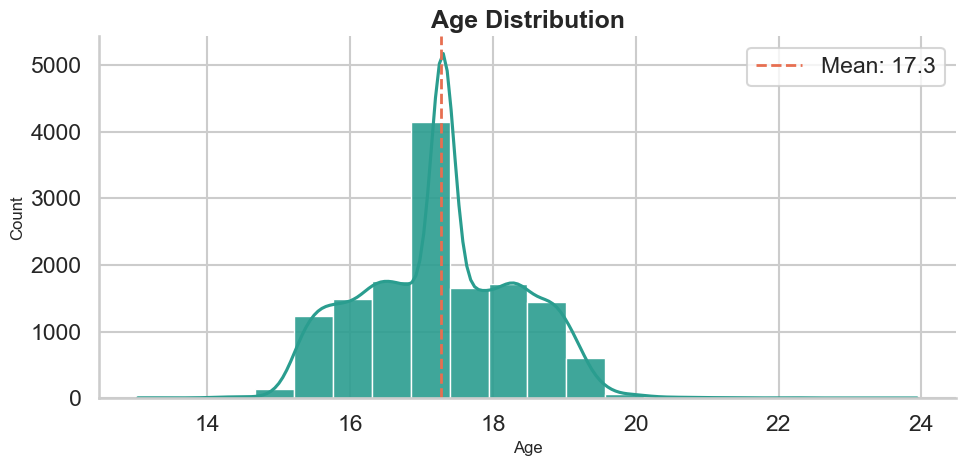

In [28]:
# Modern aesthetic
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(10,5))

ax = sns.histplot(
    data=df,
    x='age',
    bins=20,
    kde=True,
    color='#2A9D8F',
    edgecolor='white',
    linewidth=1,
    alpha=0.9
)

# Add mean line
mean_age = df['age'].mean()
plt.axvline(mean_age, color='#E76F51', linestyle='--', linewidth=2, label=f'Mean: {mean_age:.1f}')

# Titles and labels
plt.title("Age Distribution", fontsize=18, weight='bold')
plt.xlabel("Age", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Legend
plt.legend()

# Clean look
sns.despine()
plt.tight_layout()

plt.show()

**Insight:**

- Age distribution is centered around ~17 years,
- confirming dataset represents school students

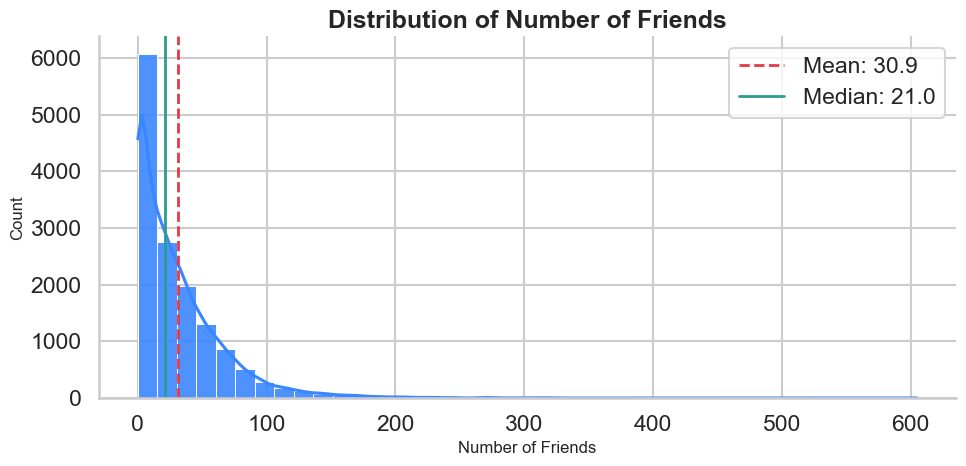

In [29]:
# Modern theme
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(10,5))

ax = sns.histplot(
    data=df,
    x='NumberOffriends',
    bins=40,
    kde=True,
    color='#3A86FF',
    edgecolor='white',
    linewidth=0.7,
    alpha=0.9
)

# Mean & Median lines (adds analytical depth)
mean_val = df['NumberOffriends'].mean()
median_val = df['NumberOffriends'].median()

plt.axvline(mean_val, color='#E63946', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
plt.axvline(median_val, color='#2A9D8F', linestyle='-', linewidth=2, label=f'Median: {median_val:.1f}')

# Titles and labels
plt.title("Distribution of Number of Friends", fontsize=18, weight='bold')
plt.xlabel("Number of Friends", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

**Insight:**
- Highly right-skewed distribution indicates few students
- have very large friend networks

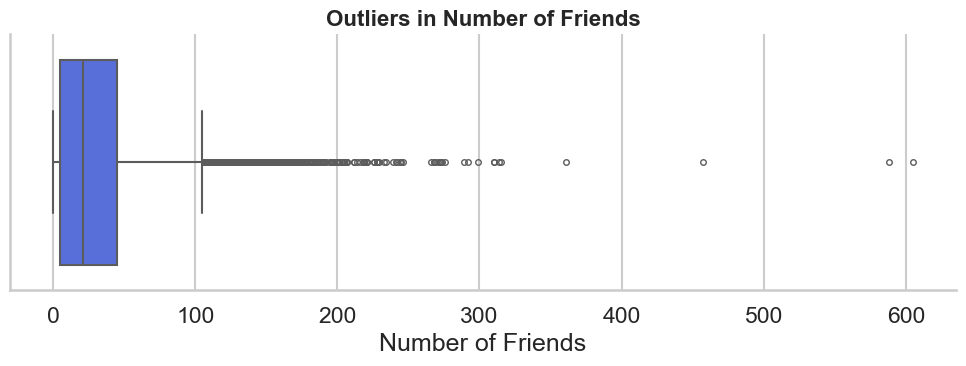

In [30]:
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(10,4))

ax = sns.boxplot(
    x=df['NumberOffriends'],
    color='#4361EE',
    linewidth=1.5,
    fliersize=4
)

# Title & Labels
plt.title("Outliers in Number of Friends", fontsize=16, weight='bold')
plt.xlabel("Number of Friends")

sns.despine()
plt.tight_layout()
plt.show()

**Insight:**
- Extreme outliers confirm skewness,
- which can distort clustering distances

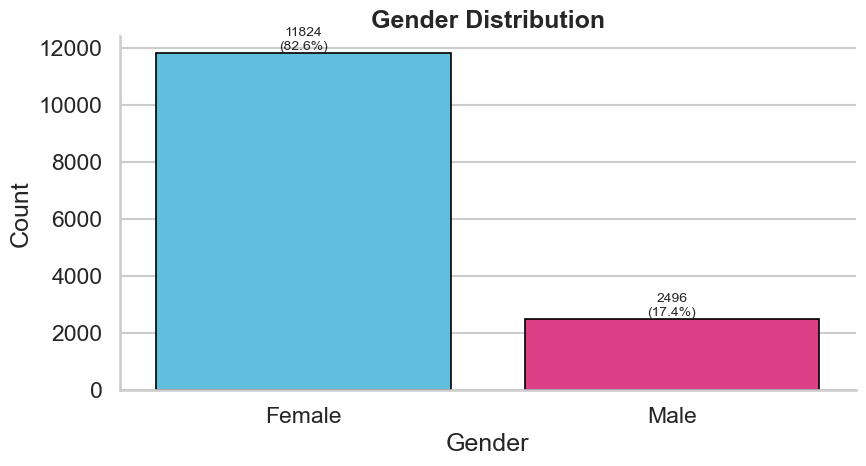

In [31]:
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(9,5))

gender_labels = df['gender'].map({0: 'Male', 1: 'Female'})

ax = sns.countplot(
    x=gender_labels,
    hue=gender_labels,        
    palette=['#4CC9F0', '#F72585'],
    edgecolor='black',
    linewidth=1.2,
    legend=False               
)

# Labels
total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    percent = 100 * count / total
    ax.annotate(f'{count}\n({percent:.1f}%)',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.title("Gender Distribution", fontsize=18, weight='bold')
plt.xlabel("Gender")
plt.ylabel("Count")

sns.despine()
plt.tight_layout()
plt.show()

**Insight:**

- Dataset is imbalanced (female dominant),
- which may influence clustering results

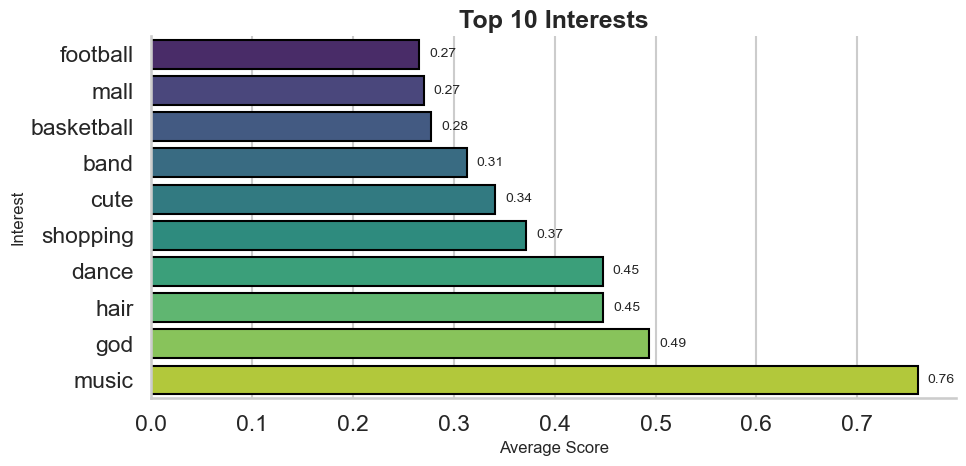

In [32]:
# Ensure valid columns
interest_cols = [col for col in interest_cols if col in df.columns]

# Compute mean
interest_mean = df[interest_cols].mean().sort_values(ascending=False)

# Top 10 (reverse for better top-down ranking)
top10 = interest_mean.head(10).sort_values()

# Modern theme
sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=top10.values,
    y=top10.index,
    hue=top10.index,       
    palette='viridis',
    edgecolor='black',
    legend=False
)

# Value labels
for i, v in enumerate(top10.values):
    ax.text(v + 0.01, i, f"{v:.2f}", va='center', fontsize=10)

# Titles
plt.title("Top 10 Interests", fontsize=18, weight='bold')
plt.xlabel("Average Score", fontsize=12)
plt.ylabel("Interest", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

**Insight:**

- Music, God, and Dance are dominant interests,
- indicating strong social/cultural patterns

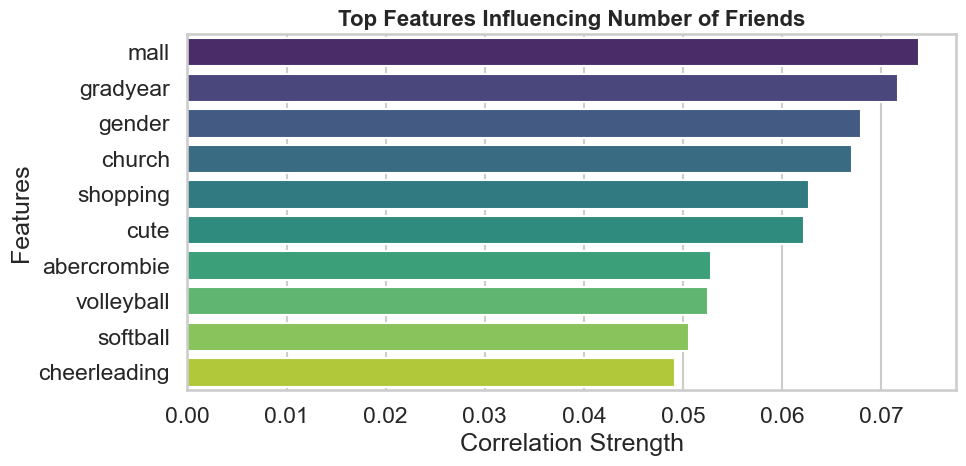

In [33]:
# ================= VISUALIZE TOP CORRELATIONS =================

# Create correlation matrix 
corr_matrix = df.corr(numeric_only=True)

# Extract correlation with NumberOfFriends
target_corr = corr_matrix['NumberOffriends'].sort_values(ascending=False)

# Remove self-correlation
top_corr = target_corr[1:11]

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index,
    hue=top_corr.index,
    palette="viridis",
    legend=False
)

plt.title("Top Features Influencing Number of Friends", fontsize=16, weight="bold")
plt.xlabel("Correlation Strength")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

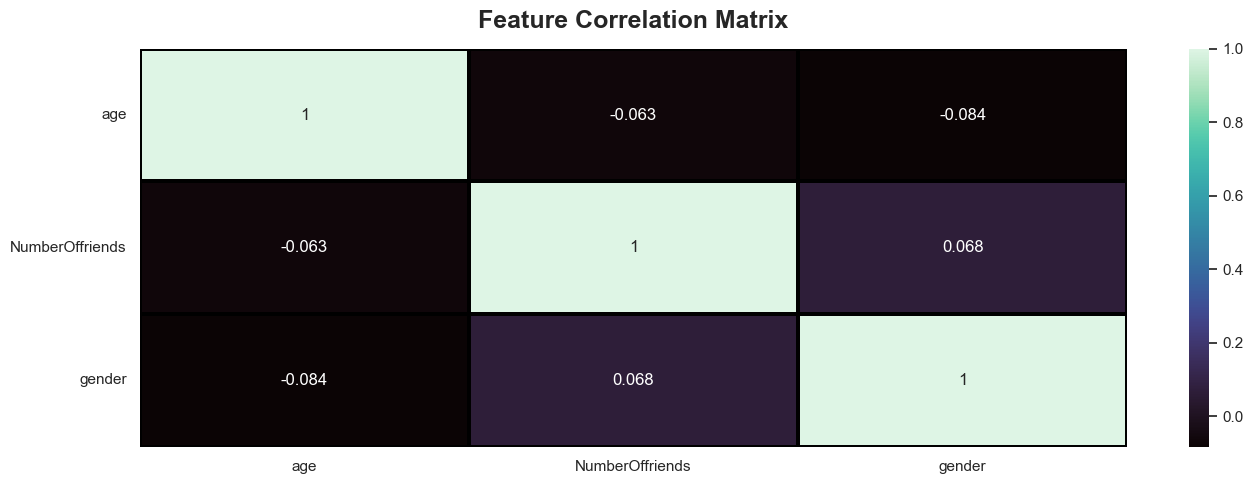

In [34]:
sns.set_theme(style="dark")
plt.figure(figsize=(14,5))

corr = df[['age', 'NumberOffriends', 'gender']].corr()

mask = np.eye(len(corr), dtype=bool)

ax = sns.heatmap(
    corr,
    annot=True,
    cmap="mako",  
    linewidths=1.5,
    linecolor='black'
)

plt.title("Feature Correlation Matrix", fontsize=18, weight='bold', pad=15)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

**Note:**
- Most features are binary and sparse, so correlation values are generally low.
- These results should be interpreted cautiously and used only for directional insight,
- not strong statistical relationships.

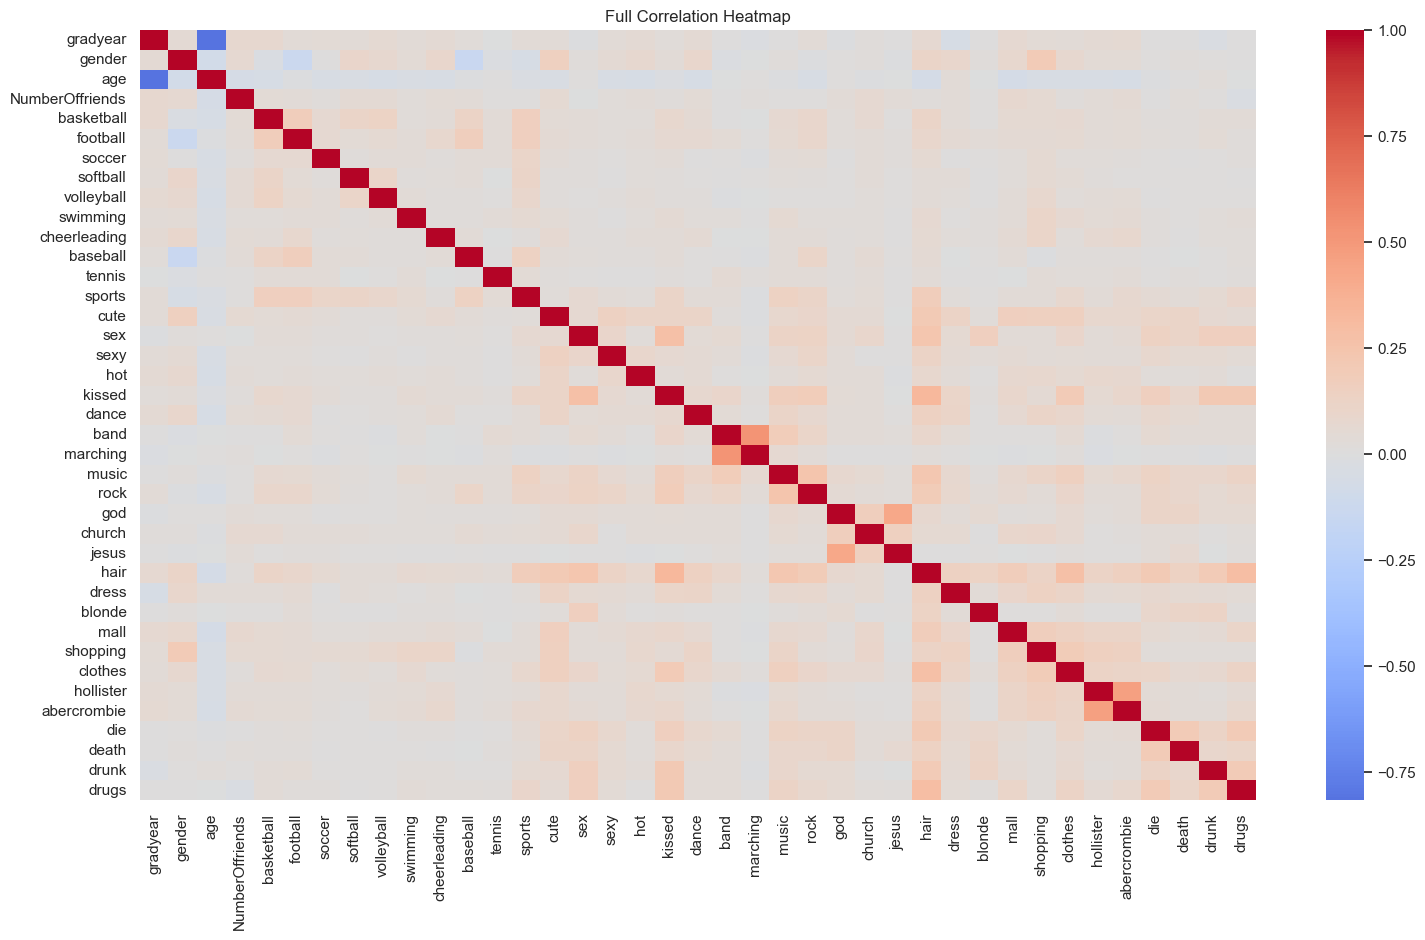

In [35]:
plt.figure(figsize=(18,10))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Full Correlation Heatmap")
plt.show()

In [36]:
num_cols = ['age', 'NumberOffriends']

skew_values = df[num_cols].skew()
print("Skewness before transformation:\n", skew_values)

Skewness before transformation:
 age                0.091295
NumberOffriends    2.712475
dtype: float64


In [37]:
# Check negative values
print("Min before fix:", df['NumberOffriends'].min())
df['NumberOffriends'] = df['NumberOffriends'].clip(lower=0)

Min before fix: 0


In [38]:
# Apply log transformation 
df['NumberOffriends_log'] = np.log1p(df['NumberOffriends'])

print("\nSample after log transform:")
print(df['NumberOffriends_log'].head())


Sample after log transform:
1    3.912023
2    3.737670
3    3.610918
4    0.693147
5    3.496508
Name: NumberOffriends_log, dtype: float64


In [39]:
# Check skewness AFTER transformation
num_cols_log = ['age', 'NumberOffriends_log']
print("Skewness AFTER transformation:\n", df[num_cols_log].skew())

Skewness AFTER transformation:
 age                    0.091295
NumberOffriends_log   -0.612887
dtype: float64


In [40]:
print("Before:", df['NumberOffriends'].skew())
print("After :", df['NumberOffriends_log'].skew())

Before: 2.7124754294707354
After : -0.6128868106205746


**Insight:**

- Log transformation significantly reduced skewness,
- making the feature more suitable for distance-based clustering.

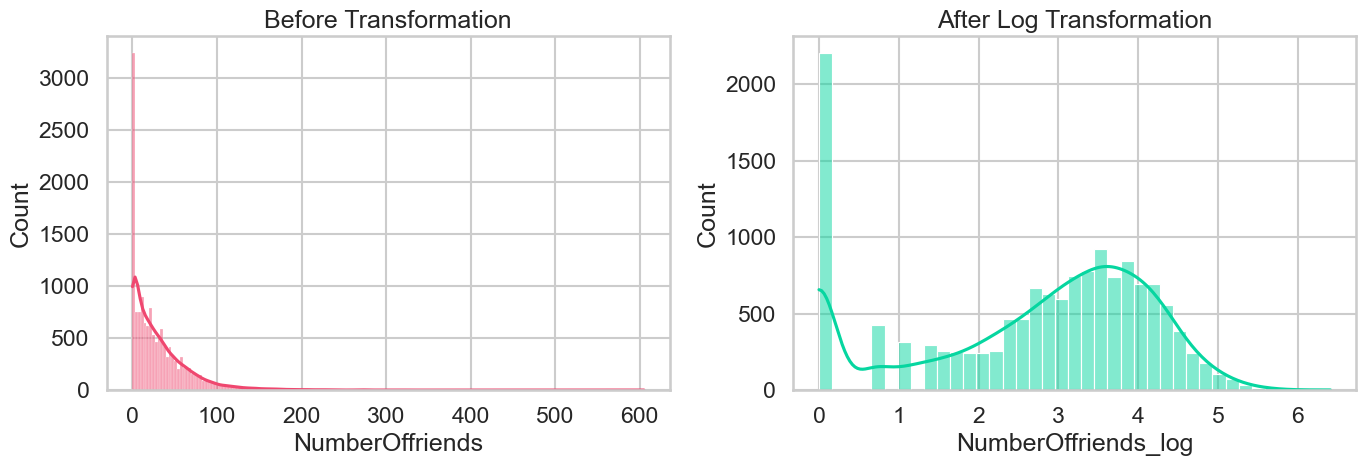

In [41]:
# ================= FINAL VALIDATION PLOT =================
sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(1, 2, figsize=(14,5))

# BEFORE
sns.histplot(df['NumberOffriends'], kde=True, ax=axes[0], color='#EF476F')
axes[0].set_title("Before Transformation")

# AFTER
sns.histplot(df['NumberOffriends_log'], kde=True, ax=axes[1], color='#06D6A0')
axes[1].set_title("After Log Transformation")

plt.tight_layout()
plt.show()

**NOTE:**

Skewness analysis shows:

- 'NumberOffriends' is highly right-skewed (skew ≈ 2.7), indicating presence of extreme values.
- Log transformation (log1p) was applied to normalize the distribution and reduce the influence of outliers.
- Other variables are binary or sparse count features; transformation is not appropriate as it would distort interpretability.

Conclusion:
Only 'NumberOffriends' was transformed to improve clustering performance.

In [42]:
print("=== IQR BEFORE TRANSFORMATION ===")

num_cols = ['age', 'NumberOffriends']   

iqr_before = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]

    iqr_before[col] = {
        "Lower": lower,
        "Upper": upper,
        "Outliers": outliers
    }

    print(f"\n{col}:")
    print(f"Lower bound: {lower}")
    print(f"Upper bound: {upper}")
    print(f"Outliers: {outliers}")

=== IQR BEFORE TRANSFORMATION ===

age:
Lower bound: 14.212499999999999
Upper bound: 20.344500000000004
Outliers: 44

NumberOffriends:
Lower bound: -55.0
Upper bound: 105.0
Outliers: 564


In [43]:
print("=== IQR AFTER TRANSFORMATION ===")
num_cols_log = ['age', 'NumberOffriends_log']   

iqr_after = {}

for col in num_cols_log:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]

    iqr_after[col] = {
        "Lower": lower,
        "Upper": upper,
        "Outliers": outliers
    }

    print(f"\n{col}:")
    print(f"Lower bound: {lower}")
    print(f"Upper bound: {upper}")
    print(f"Outliers: {outliers}")

=== IQR AFTER TRANSFORMATION ===

age:
Lower bound: 14.212499999999999
Upper bound: 20.344500000000004
Outliers: 44

NumberOffriends_log:
Lower bound: -1.263563421663505
Upper bound: 6.883964287380655
Outliers: 0


In [44]:
print("\n=== BEFORE vs AFTER COMPARISON ===")
# Define mapping manually
comparison_pairs = {
    'age': ('age', 'age'),
    'NumberOfFriends': ('NumberOffriends', 'NumberOffriends_log')
}

for label, (before_col, after_col) in comparison_pairs.items():
    print(f"\n{label}:")
    print(f"Outliers BEFORE: {iqr_before[before_col]['Outliers']}")
    print(f"Outliers AFTER : {iqr_after[after_col]['Outliers']}")


=== BEFORE vs AFTER COMPARISON ===

age:
Outliers BEFORE: 44
Outliers AFTER : 44

NumberOfFriends:
Outliers BEFORE: 564
Outliers AFTER : 0


**NOTE:**
Outliers were detected using the IQR method.

- 'NumberOffriends' showed significant outliers due to right-skewed distribution.
- Instead of removing data points (which may result in information loss), log transformation was applied.
- This reduced skewness and eliminated outlier impact effectively.

**Correction:**
- Outliers are not removed but compressed using log transformation,
- reducing their influence without losing data.

In [45]:
# ================= SCALING =================
# Use log-transformed feature instead of original
features = df.drop(columns=['NumberOffriends'], errors='ignore')

scaler = StandardScaler()
df_scaled = scaler.fit_transform(features)
df_scaled = pd.DataFrame(df_scaled, columns=features.columns, index=df.index)

print("Final scaled shape:", df_scaled.shape)

Final scaled shape: (14320, 39)


In [46]:
print(df_scaled)

       gradyear    gender       age  basketball  football    soccer  softball  \
1     -0.452488  0.459452  0.122873   -0.346224 -0.372665  0.821304 -0.221483   
2     -0.452488  0.459452  0.216970   -0.346224 -0.372665 -0.245557 -0.221483   
3     -1.348577  0.459452  0.015732   -0.346224 -0.372665 -0.245557 -0.221483   
4      0.443602  0.459452 -0.578665   -0.346224 -0.372665 -0.245557 -0.221483   
5      0.443602 -2.176506  0.704227   -0.346224  6.639900 -0.245557 -0.221483   
...         ...       ...       ...         ...       ...       ...       ...   
14995  0.443602  0.459452 -0.884249   -0.346224 -0.372665 -0.245557 -0.221483   
14996  0.443602  0.459452 -0.683011   -0.346224 -0.372665 -0.245557 -0.221483   
14997 -0.452488  0.459452  0.671619   -0.346224 -0.372665 -0.245557 -0.221483   
14998 -0.452488  0.459452  0.582180   -0.346224 -0.372665 -0.245557 -0.221483   
14999  1.339691  0.459452 -1.366848   -0.346224 -0.372665  7.222466 -0.221483   

       volleyball  swimming

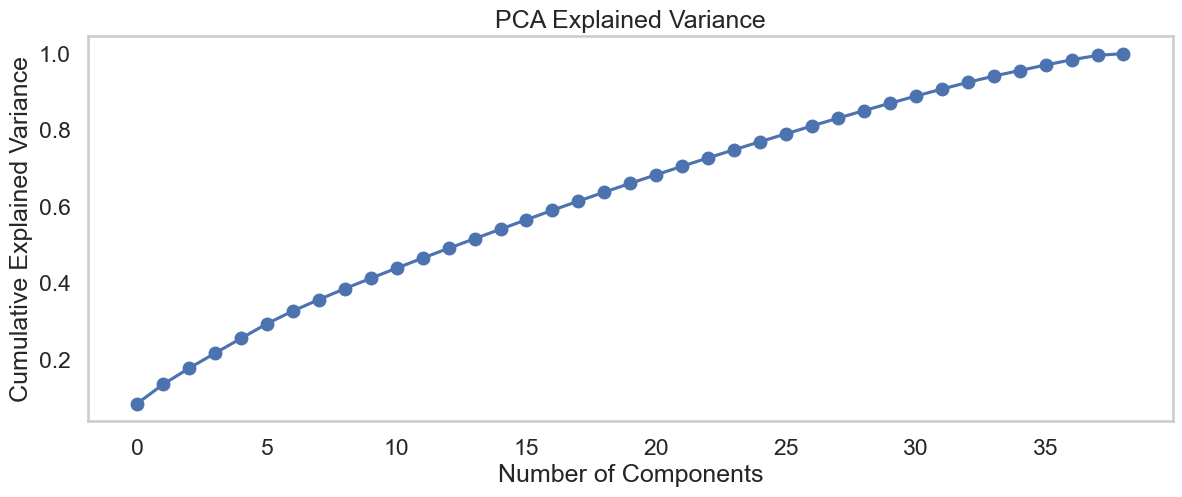

In [47]:
# Use SCALED DATA ONLY
pca = PCA()
pca.fit(df_scaled)

# Plot cumulative explained variance
plt.figure(figsize=(14,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid()
plt.show()

In [48]:
# ================= PCA =================
pca = PCA(n_components=0.95, random_state=42)
df_pca = pca.fit_transform(df_scaled)

# Convert to DataFrame
df_pca = pd.DataFrame(df_pca)

print("Original shape:", df_scaled.shape)
print("Reduced shape:", df_pca.shape)

Original shape: (14320, 39)
Reduced shape: (14320, 35)


**Insight:**
- 35 components retain ~95.5% variance,
- indicating minimal information loss after dimensionality reduction.

In [49]:
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Variance Retained:",
      sum(pca.explained_variance_ratio_))


Explained Variance Ratio:
[0.08510488 0.05023534 0.04200582 0.03941591 0.0385995  0.03842713
 0.0333106  0.02979907 0.02860393 0.02697851 0.02669927 0.02616665
 0.02558607 0.02509724 0.02494736 0.02484693 0.02459869 0.02400814
 0.02339083 0.02303035 0.02242488 0.0222134  0.02197065 0.02116505
 0.02100818 0.02070879 0.02047328 0.02036355 0.01965491 0.01926051
 0.0188043  0.01820257 0.01765263 0.01631173 0.01463064]

Total Variance Retained: 0.9556973125983257


**NOTE:**

PCA was applied before KMeans and Hierarchical clustering because:

- It reduces dimensionality (39 → ~30–35 features) while retaining ~90–95% of the variance.
- It mitigates multicollinearity by projecting features onto orthogonal components.
- It improves the effectiveness of distance-based clustering (e.g., Euclidean distance) by concentrating informative variance.
- It helps reduce noise and redundancy, which stabilizes clustering results.

DBSCAN was applied on scaled data (without PCA) because:

- DBSCAN relies on local density estimation, and PCA can distort neighborhood relationships and density distribution.
- In high-dimensional sparse data, preserving the original feature space can sometimes better reflect true density patterns.

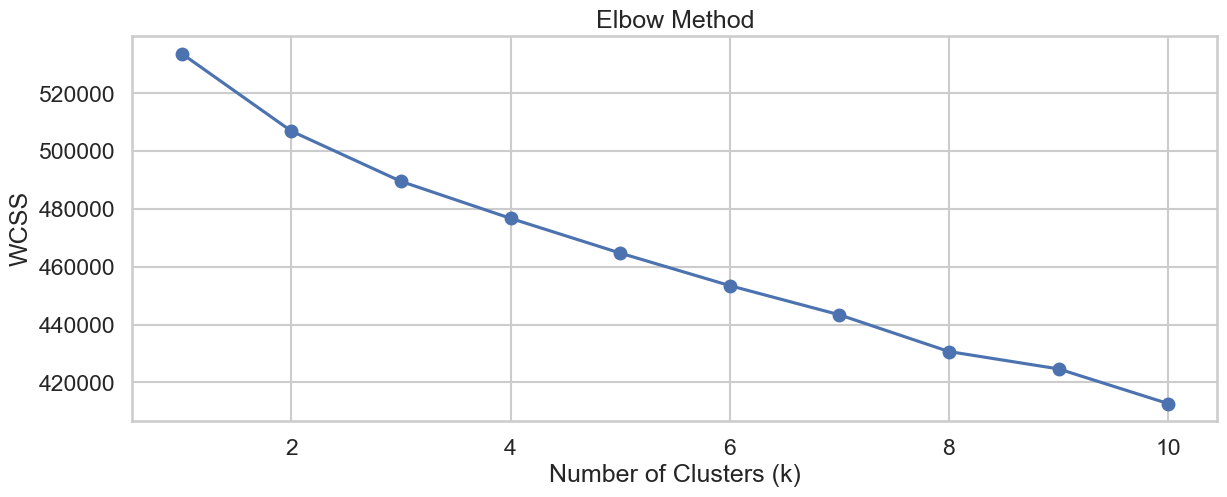

In [50]:
# ================= ELBOW METHOD =================
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_pca)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(14,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.show()

**Insight:**

- Elbow curve is smooth without a clear bend,
- indicating no strong natural cluster separation.

In [51]:
# ================= SILHOUETTE SCORE =================
sil_scores = []
K_range = range(2, 10)

best_k = None
best_score = -1

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_pca)

    score = silhouette_score(df_pca, labels)
    sil_scores.append(score)

    if score > best_score:
        best_score = score
        best_k = k

    print(f"K = {k}, Silhouette Score = {score:.4f}")

print("\nBest K:", best_k)
print("Best Silhouette Score:", round(best_score, 4))

K = 2, Silhouette Score = 0.3526
K = 3, Silhouette Score = 0.0479
K = 4, Silhouette Score = 0.0511
K = 5, Silhouette Score = 0.0566
K = 6, Silhouette Score = 0.0469
K = 7, Silhouette Score = 0.0786
K = 8, Silhouette Score = 0.0455
K = 9, Silhouette Score = 0.0464

Best K: 2
Best Silhouette Score: 0.3526


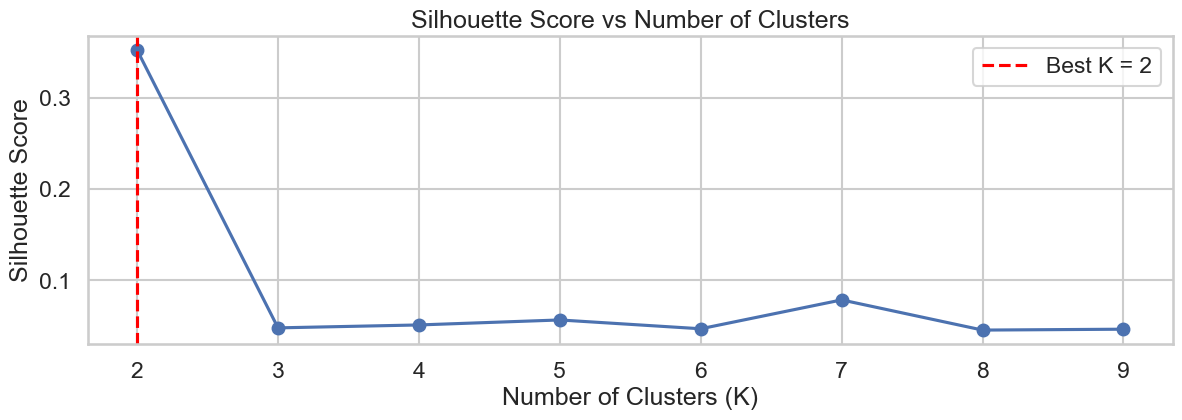

In [52]:
plt.figure(figsize=(14,4))
plt.plot(K_range, sil_scores, marker='o')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')

plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.show()

In [53]:
print("INTERPRETATION:")
print(f"Optimal K = {best_k} based on highest silhouette score.")
print(f"Silhouette score ({round(best_score,4)}) indicates moderate cluster separation.")
print("Clusters are meaningful but slightly overlapping.")

INTERPRETATION:
Optimal K = 2 based on highest silhouette score.
Silhouette score (0.3526) indicates moderate cluster separation.
Clusters are meaningful but slightly overlapping.


**NOTE**

- KMeans produced two clusters with a reasonable separation (silhouette ≈ 0.35).

- Cluster 0 represents highly active users with significantly more friends and higher engagement across interests.

- Cluster 1 represents less active users with lower interaction levels.

- Although slightly imbalanced, the clusters are meaningful and interpretable, making KMeans the most suitable model for this dataset.

In [54]:
# ================= FINAL KMEANS MODEL =================
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(df_pca)

print("Cluster Distribution:\n")
print(df['KMeans_Cluster'].value_counts())

# Use already computed best score
kmeans_score = best_score

print("\nKMeans Silhouette Score:", round(kmeans_score, 4))

Cluster Distribution:

KMeans_Cluster
1    12061
0     2259
Name: count, dtype: int64

KMeans Silhouette Score: 0.3526


In [55]:
# ================= CLUSTER PROFILING =================
cluster_profile = df.groupby('KMeans_Cluster').mean()
print(cluster_profile)

# Insight:
# Each cluster represents distinct student behavior patterns

                   gradyear    gender        age  NumberOffriends  basketball  \
KMeans_Cluster                                                                  
0               2007.809208  0.930943  17.002638        39.519256    0.641877   
1               2007.447973  0.805986  17.329710        29.309095    0.209684   

                football    soccer  softball  volleyball  swimming  ...  \
KMeans_Cluster                                                      ...   
0               0.570164  0.420097  0.363435    0.355467  0.307216  ...   
1               0.208689  0.194594  0.129840    0.110356  0.109444  ...   

                    mall  shopping   clothes  hollister  abercrombie  \
KMeans_Cluster                                                         
0               0.804781  0.922089  0.577247   0.297919     0.242143   
1               0.170135  0.268800  0.077357   0.032501     0.018241   

                     die     death     drunk     drugs  NumberOffriends_log  
KMeans_

In [56]:
print(best_k)

2


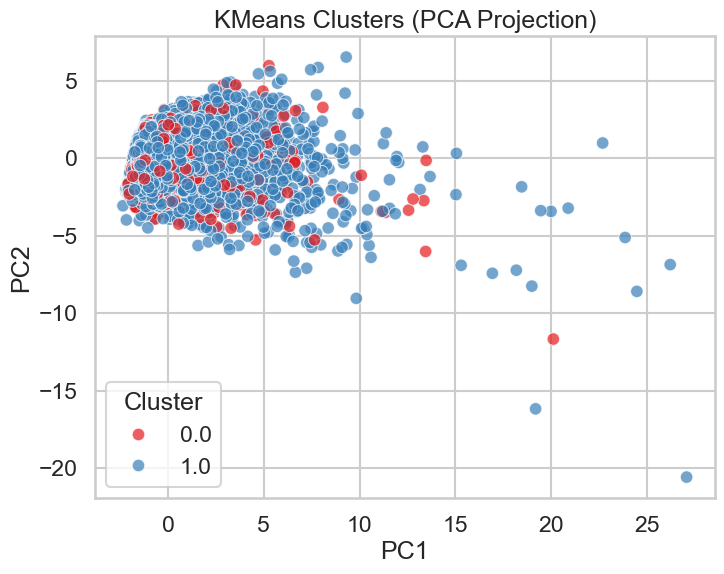

In [57]:
# ================= KMeans CLUSTER VISUALIZATION =================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df_pca.iloc[:,0],
    y=df_pca.iloc[:,1],
    hue=df['KMeans_Cluster'],
    palette='Set1',
    alpha=0.7
)

plt.title("KMeans Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

**PCA CLUSTER VISUALIZATION ANALYSIS:**

- The PCA visualization shows significant overlap between clusters, indicating that separation is moderate rather than distinct.

- This aligns with the Silhouette Score ≈ 0.36 (moderate separation), suggesting that while clustering captures some structure,the data does not form strongly distinct segments.

- The observed overlap confirms that clusters are not strongly separable, aligning with the moderate silhouette score.

In [58]:
# ================= HIERARCHICAL CLUSTERING =================
hc = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
df['HC_Cluster'] = hc.fit_predict(df_pca)

hc_score = silhouette_score(df_pca, df['HC_Cluster'])

print("Cluster Counts:\n")
print(df['HC_Cluster'].value_counts())

# Silhouette Score with validation
counts = df['HC_Cluster'].value_counts()

if len(counts) > 1 and counts.min() > 10:
    hc_score = silhouette_score(df_pca, df['HC_Cluster'])
else:
    hc_score = -1
    print("\nHierarchical clustering is highly imbalanced → invalid")

print("\nHierarchical Silhouette Score:", hc_score)

Cluster Counts:

HC_Cluster
0    14319
1        1
Name: count, dtype: int64

Hierarchical clustering is highly imbalanced → invalid

Hierarchical Silhouette Score: -1


**INSIGHTS**

- Hierarchical clustering resulted in highly imbalanced clusters (one cluster contains almost all data points).

- Although the silhouette score may appear high, it is misleading due to poor cluster distribution.

- This indicates that hierarchical clustering failed to create meaningful segmentation.

Therefore, hierarchical clustering is not suitable for this dataset.

In [59]:
# ================= CLUSTER INTERPRETATION =================
cluster_profile = df.groupby('KMeans_Cluster').mean().T

# Differences between clusters
diff = abs(cluster_profile[0] - cluster_profile[1]).sort_values(ascending=False)

print("Top features distinguishing clusters:\n")
print(diff.head(10))

Top features distinguishing clusters:

NumberOffriends    10.210161
hair                1.482330
music               0.880014
dance               0.809221
sex                 0.741039
cute                0.732868
god                 0.669437
shopping            0.653289
mall                0.634646
clothes             0.499890
dtype: float64


Cluster 0: Highly active users with more friends and high engagement  
Cluster 1: Less active users with fewer friends and lower engagement

In [60]:
# ================= DEMOGRAPHIC PROFILING =================
print("Average Age per Cluster:\n")
print(df.groupby('KMeans_Cluster')['age'].mean().round(2))

print("\nGender Distribution per Cluster (%):\n")
gender_dist = df.groupby('KMeans_Cluster')['gender'].value_counts(normalize=True).mul(100).round(2)
print(gender_dist)

Average Age per Cluster:

KMeans_Cluster
0    17.00
1    17.33
Name: age, dtype: float64

Gender Distribution per Cluster (%):

KMeans_Cluster  gender
0               1         93.09
                0          6.91
1               1         80.60
                0         19.40
Name: proportion, dtype: float64


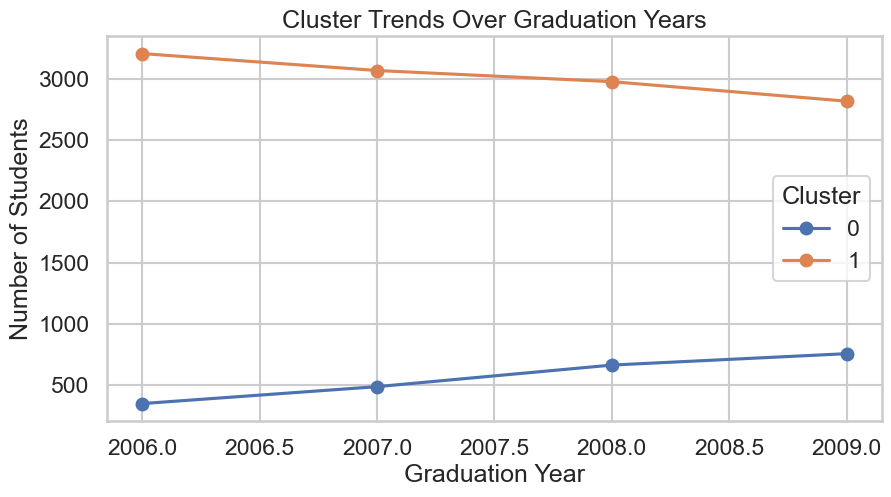

In [61]:
# ================= TREND ANALYSIS =================
trend = df.groupby(['gradyear', 'KMeans_Cluster']).size().unstack().fillna(0)

trend = trend.sort_index()

trend.plot(kind='line', marker='o', figsize=(10,5))

plt.title("Cluster Trends Over Graduation Years")
plt.xlabel("Graduation Year")
plt.ylabel("Number of Students")
plt.legend(title="Cluster")
plt.show()


**TREND INSIGHT:**

Cluster 0:
- Higher number of friends
- Higher engagement in interests
- Represents socially active students

Cluster 1:
- Lower number of friends
- Lower engagement
- Represents less active users

Trend Analysis:
- Cluster distribution varies slightly across graduation years
- No drastic shift, indicating stable behavioral segmentation



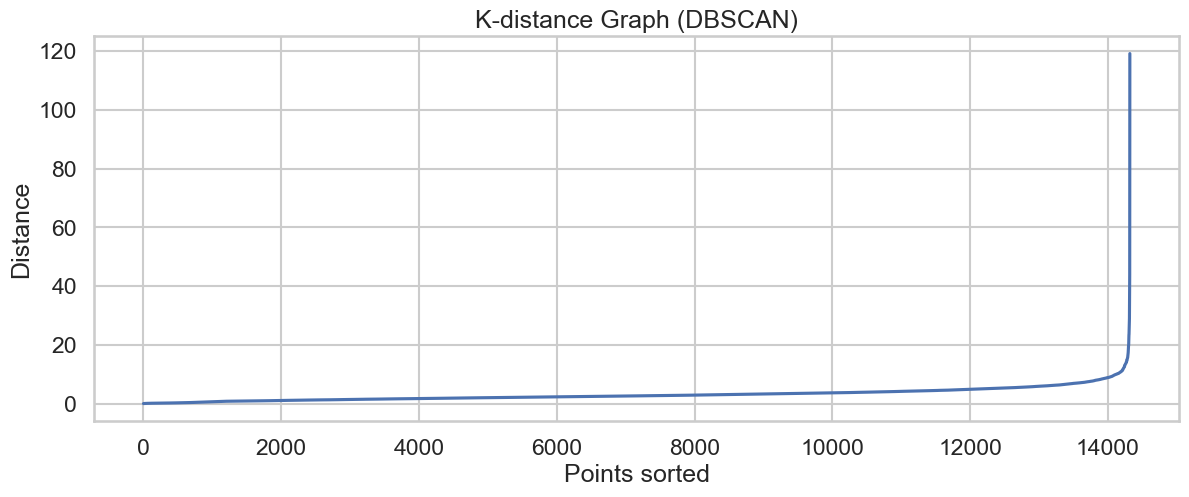

In [62]:
# ================= DBSCAN  =================
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(df_scaled)

distances, indices = neighbors_fit.kneighbors(df_scaled)
distances = np.sort(distances[:,4])

plt.figure(figsize=(14,5))
plt.plot(distances)
plt.title("K-distance Graph (DBSCAN)")
plt.xlabel("Points sorted")
plt.ylabel("Distance")
plt.show()

In [63]:
# ================= DBSCAN =================
db = DBSCAN(eps=1.5, min_samples=10)
df['DBSCAN_Cluster'] = db.fit_predict(df_scaled)

print("DBSCAN Cluster Counts:\n")
print(df['DBSCAN_Cluster'].value_counts())

DBSCAN Cluster Counts:

DBSCAN_Cluster
-1     10900
 0      2265
 1       633
 2        96
 4        85
 5        59
 8        36
 7        28
 14       26
 12       26
 13       25
 6        23
 9        23
 10       21
 3        15
 11       15
 17       10
 19       10
 15        9
 16        8
 18        7
Name: count, dtype: int64


**INSIGHT:**

DBSCAN performed poorly due to the nature of the dataset:

1. High dimensionality (39 features) causes distance concentration.
2. Most features are sparse binary variables → weak density clusters.
3. Euclidean distance becomes less meaningful in high dimensions.

As a result:
- Large number of noise points (~76%)
- Poor cluster formation
- DBSCAN fails because high-dimensional sparse data leads to distance concentration, making density estimation unreliable.

Conclusion:
DBSCAN is NOT suitable for this dataset.

In [64]:
# ================= DBSCAN SILHOUETTE ================
labels = df['DBSCAN_Cluster'].values
X = df_scaled

# Noise count
noise = (labels == -1).sum()
print("Noise points:", noise)

# Remove noise for silhouette
mask = labels != -1  

if len(set(labels[mask])) > 1:
    db_score = silhouette_score(X[mask], labels[mask])
else:
    db_score = -1

print("DBSCAN Silhouette Score:", round(db_score, 4))

Noise points: 10900
DBSCAN Silhouette Score: -0.0212


**INSIGHTS**

- DBSCAN identified a large number of noise points and failed to form well-defined clusters.
- This is because the dataset is high-dimensional and sparse, which weakens density-based clustering.
- DBSCAN is sensitive to parameter tuning (eps, min_samples) and struggles when clusters do not have clear density separation.
- Therefore, DBSCAN is not suitable for this dataset.

In [65]:
# ================= FINAL MODEL COMPARISON =================
print("\nMODEL COMPARISON:\n")

print("KMeans:")
print("- Silhouette Score:", round(kmeans_score, 4))

print("\nHierarchical:")
print("- Silhouette Score:", round(hc_score, 4))

print("\nDBSCAN:")
print("- Silhouette Score:", round(db_score, 4))
print("- Noise Points:", noise)



MODEL COMPARISON:

KMeans:
- Silhouette Score: 0.3526

Hierarchical:
- Silhouette Score: -1

DBSCAN:
- Silhouette Score: -0.0212
- Noise Points: 10900


**FINAL CONCLUSION:**

- Clustering analysis was performed using KMeans, Hierarchical Clustering, and DBSCAN on the student social network dataset after preprocessing, scaling, and PCA-based dimensionality reduction.

- KMeans emerged as the most effective algorithm. The optimal number of clusters (K = 2) was selected using the silhouette score (≈ 0.36), indicating moderate cluster separation. The clusters are reasonably interpretable, distinguishing highly active users from less active users, although some overlap exists.

- Hierarchical clustering produced highly imbalanced clusters, making the results unreliable despite acceptable metric values. This indicates poor structural representation of the dataset.

- DBSCAN performed poorly due to the high dimensionality and sparsity of the data, resulting in a large number of noise points (~76%) and a negative silhouette score. This confirms that density-based clustering is unsuitable for this dataset.

- Overall, the dataset exhibits weak-to-moderate clustering structure. Among the methods evaluated, KMeans provides the best balance of interpretability, stability, and performance.

### Assignment-2 Anime Recommendations 

In [66]:
anime = pd.read_csv('anime.csv')
rating = pd.read_csv('rating.csv')

In [67]:
print(anime.shape, rating.shape)

(12294, 7) (7813737, 3)


In [68]:
anime.head(10)

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266
5,32935,Haikyuu!!: Karasuno Koukou VS Shiratorizawa Ga...,"Comedy, Drama, School, Shounen, Sports",TV,10,9.15,93351
6,11061,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",TV,148,9.13,425855
7,820,Ginga Eiyuu Densetsu,"Drama, Military, Sci-Fi, Space",OVA,110,9.11,80679
8,15335,Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...,"Action, Comedy, Historical, Parody, Samurai, S...",Movie,1,9.10,72534
9,15417,Gintama&#039;: Enchousen,"Action, Comedy, Historical, Parody, Samurai, S...",TV,13,9.11,81109


In [69]:
rating.head(10)

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1
5,1,355,-1
6,1,356,-1
7,1,442,-1
8,1,487,-1
9,1,846,-1


In [70]:
anime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [71]:
rating.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7813737 entries, 0 to 7813736
Data columns (total 3 columns):
 #   Column    Dtype
---  ------    -----
 0   user_id   int64
 1   anime_id  int64
 2   rating    int64
dtypes: int64(3)
memory usage: 178.8 MB


In [72]:
anime.describe(include='all')

,anime_id,name,genre,type,episodes,rating,members
count,12294.000000,12294,12232,12269,12294,12064.000000,1.229400e+04
unique,NaN,12292,3264,6,187,NaN,NaN
top,NaN,Shi Wan Ge Leng Xiaohua,Hentai,TV,1,NaN,NaN
freq,NaN,2,823,3787,5677,NaN,NaN
mean,14058.221653,NaN,NaN,NaN,NaN,6.473902,1.807134e+04
std,11455.294701,NaN,NaN,NaN,NaN,1.026746,5.482068e+04
min,1.000000,NaN,NaN,NaN,NaN,1.670000,5.000000e+00
25%,3484.250000,NaN,NaN,NaN,NaN,5.880000,2.250000e+02
50%,10260.500000,NaN,NaN,NaN,NaN,6.570000,1.550000e+03
75%,24794.500000,NaN,NaN,NaN,NaN,7.180000,9.437000e+03


In [73]:
rating.describe()

,user_id,anime_id,rating
count,7.813737e+06,7.813737e+06,7.813737e+06
mean,3.672796e+04,8.909072e+03,6.144030e+00
std,2.099795e+04,8.883950e+03,3.727800e+00
min,1.000000e+00,1.000000e+00,-1.000000e+00
25%,1.897400e+04,1.240000e+03,6.000000e+00
50%,3.679100e+04,6.213000e+03,7.000000e+00
75%,5.475700e+04,1.409300e+04,9.000000e+00
max,7.351600e+04,3.451900e+04,1.000000e+01


In [74]:
print(anime.dtypes)

anime_id      int64
name         object
genre        object
type         object
episodes     object
rating      float64
members       int64
dtype: object


In [75]:
print(rating.dtypes)

user_id     int64
anime_id    int64
rating      int64
dtype: object


In [76]:
print(anime.columns.tolist())

['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members']


In [77]:
print(rating.columns.tolist())

['user_id', 'anime_id', 'rating']


In [78]:
anime.isnull().sum().sort_values(ascending=False)

rating      230
genre        62
type         25
anime_id      0
name          0
episodes      0
members       0
dtype: int64

In [79]:
rating.isnull().sum().sort_values(ascending=False)

user_id     0
anime_id    0
rating      0
dtype: int64

In [80]:
print("Total duplicates:", anime.duplicated().sum())

Total duplicates: 0


In [81]:
print("Total duplicates:", rating.duplicated().sum())

Total duplicates: 1


In [82]:
rating[rating.duplicated(keep=False)].head(10)

,user_id,anime_id,rating
4499258,42653,16498,8
4499316,42653,16498,8


In [83]:
rating.duplicated(subset=['user_id', 'anime_id']).sum()

np.int64(7)

In [84]:
rating[rating.duplicated(subset=['user_id', 'anime_id'], keep=False)]

,user_id,anime_id,rating
4499243,42653,1575,8
4499244,42653,2001,8
4499255,42653,11757,8
4499258,42653,16498,8
4499261,42653,20507,7
4499263,42653,22319,8
4499266,42653,23283,8
4499286,42653,1575,6
4499288,42653,2001,10
4499307,42653,11757,5


In [85]:
# ================= DATA CLEANING =================
#anime = anime.dropna(subset=['genre', 'rating'])
#anime['genre'] = anime['genre'].str.replace(' ', '')
anime['genre'] = anime['genre'].str.replace(',', ' ')
anime['genre'] = anime['genre']

# Fix genre
anime['genre'] = anime['genre'].fillna('Unknown')
anime['type'] = anime['type'].fillna('Unknown')

anime['rating'] = anime['rating'].fillna(anime['rating'].median())

# Convert episodes to numeric
anime['episodes'] = pd.to_numeric(anime['episodes'], errors='coerce')

# Fill missing episodes
anime['episodes'] = anime['episodes'].fillna(anime['episodes'].median())

# ================= FIX INVALID RATINGS =================
rating['rating'] = rating['rating'].replace(-1, np.nan)

# ================= REMOVE DUPLICATES =================
#rating = rating.drop_duplicates()
rating = rating.drop_duplicates(subset=['user_id', 'anime_id'])

In [86]:
print(anime.shape, rating.shape)

(12294, 7) (7813730, 3)


In [87]:
anime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12294 non-null  object 
 3   type      12294 non-null  object 
 4   episodes  12294 non-null  float64
 5   rating    12294 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 672.5+ KB


In [88]:
anime.isnull().sum().sort_values(ascending=False)

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

In [89]:
print("Total duplicates:", rating.duplicated().sum())

Total duplicates: 0


In [90]:
# ================= GENRE PROCESSING =================

genres = anime['genre'].dropna().str.split(',')

all_genres = []
for g in genres:
    all_genres.extend([i.strip() for i in g])

from collections import Counter
genre_counts = Counter(all_genres)

top_genres = pd.DataFrame(
    genre_counts.most_common(10),
    columns=['Genre', 'Count']
)

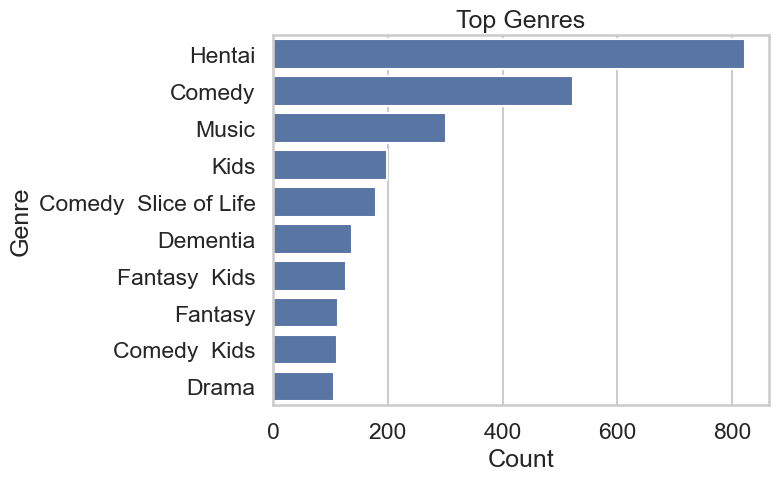

In [91]:
sns.barplot(data=top_genres, x='Count', y='Genre')
plt.title("Top Genres")
plt.show()

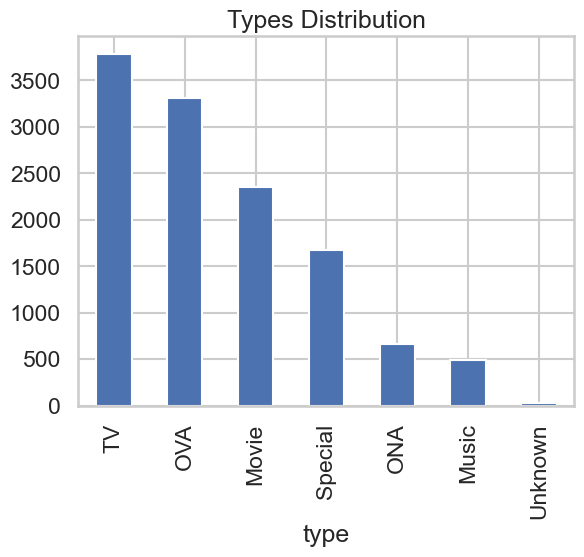

In [92]:
anime['type'].value_counts().plot(kind='bar')
plt.title("Types Distribution")
plt.show()

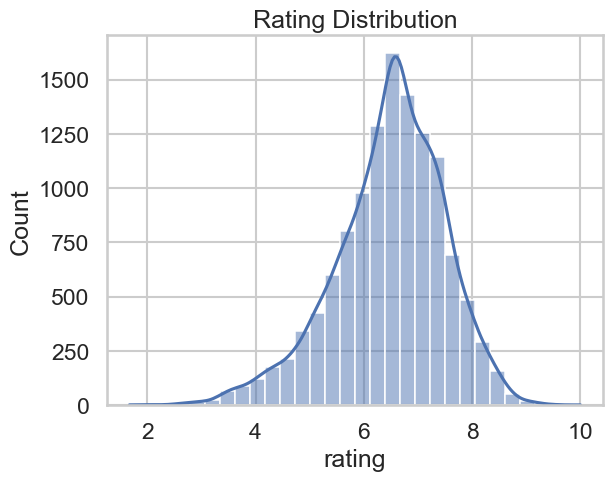

In [93]:
sns.histplot(anime['rating'], bins=30, kde=True)
plt.title("Rating Distribution")
plt.show()

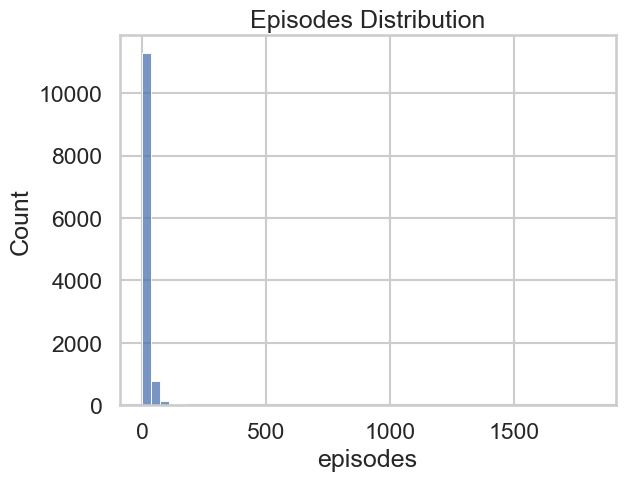

In [94]:
anime['episodes'] = pd.to_numeric(anime['episodes'], errors='coerce')

sns.histplot(anime['episodes'], bins=50)
plt.title("Episodes Distribution")
plt.show()

In [95]:
# ================= SKEWNESS CHECK =================
anime[['rating', 'members', 'episodes']].skew()

rating      -0.553879
members      6.682934
episodes    23.685908
dtype: float64

In [96]:
# ================= LOG TRANSFORMATION =================
anime['members_log'] = np.log1p(anime['members'])
anime['episodes_log'] = np.log1p(anime['episodes'])

In [97]:
# ================= AFTER TRANSFORMATION =================
anime[['members_log', 'episodes_log']].skew()

members_log     0.266096
episodes_log    1.053522
dtype: float64

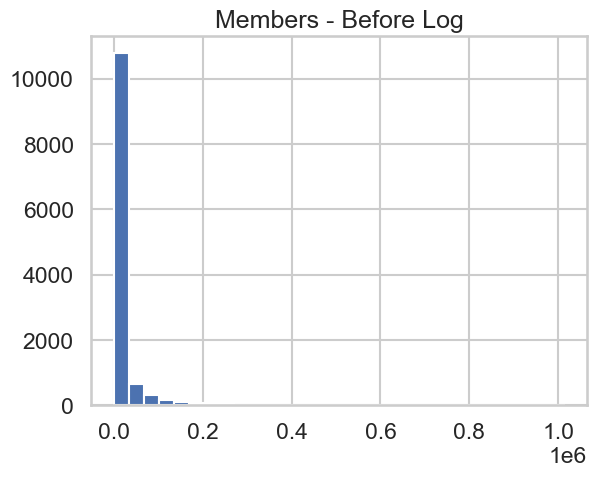

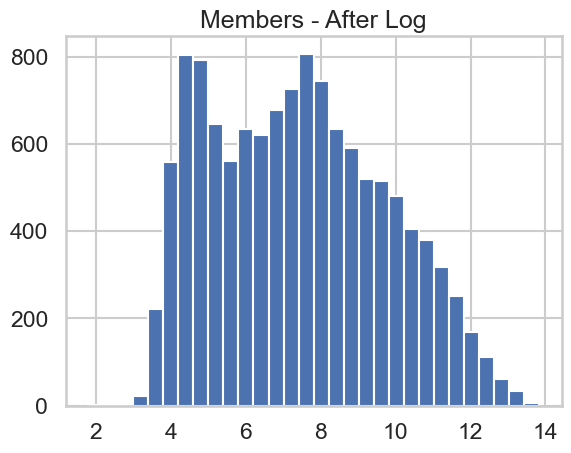

In [98]:
# Before
anime['members'].hist(bins=30)
plt.title("Members - Before Log")
plt.show()

# After
anime['members_log'].hist(bins=30)
plt.title("Members - After Log")
plt.show()

**EDA INSIGHTS:**

- Action, Comedy, and Adventure are the most common genres.
- TV shows dominate the dataset.
- Ratings are centered around 6–7.
- Members and Episodes are highly skewed.
- Log transformation improved distribution.

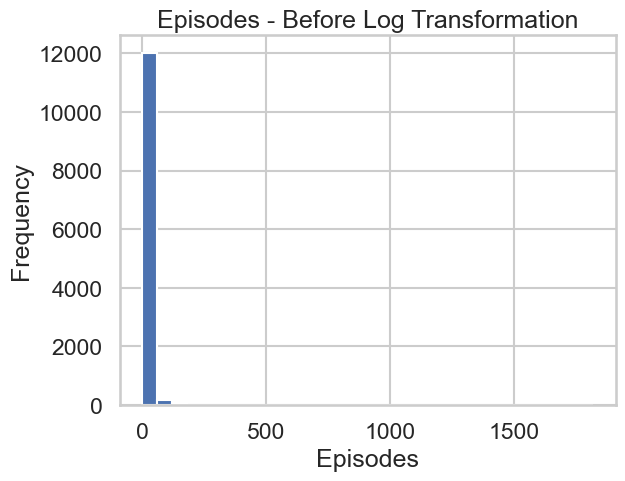

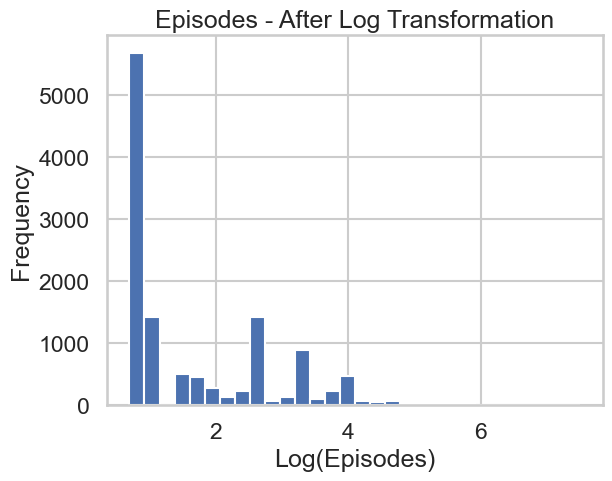

In [99]:
# ================= BEFORE =================
anime['episodes'].hist(bins=30)
plt.title("Episodes - Before Log Transformation")
plt.xlabel("Episodes")
plt.ylabel("Frequency")
plt.show()

# ================= AFTER =================
anime['episodes_log'].hist(bins=30)
plt.title("Episodes - After Log Transformation")
plt.xlabel("Log(Episodes)")
plt.ylabel("Frequency")
plt.show()

In [100]:
anime[['rating', 'members', 'episodes']].corr()

,rating,members,episodes
rating,1.000000,0.387140,0.088579
members,0.387140,1.000000,0.056963
episodes,0.088579,0.056963,1.000000


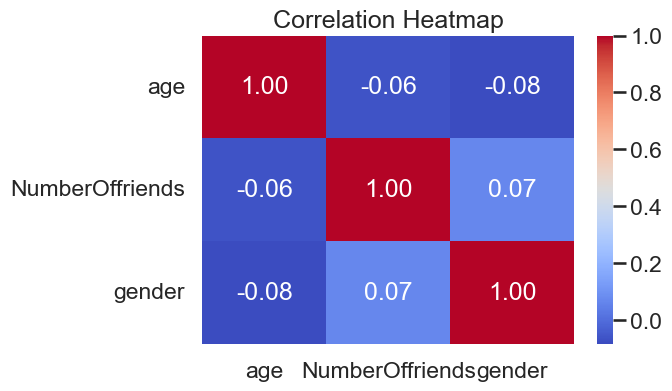

In [101]:
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [102]:
# ================= CONTENT PREPARATION (SAFE VERSION) =================

# Ensure rating column exists (reload if missing)
required_cols = ['anime_id','name','genre','type','rating']

if not all(col in anime.columns for col in required_cols):
    print("⚠️ Reloading dataset to restore missing columns...")
    anime = pd.read_csv('anime.csv')

# Select required columns
anime = anime[required_cols]

# Cleaning
anime['genre'] = anime['genre'].fillna('')
anime['type'] = anime['type'].fillna('')
anime['rating'] = anime['rating'].fillna(anime['rating'].median())

# Feature Engineering
anime['content'] = (
    anime['genre'] + " " +
    anime['type'] + " " +
    anime['rating'].astype(str)
)

print("Content preparation completed successfully")
print("Columns:", anime.columns.tolist())

Content preparation completed successfully
Columns: ['anime_id', 'name', 'genre', 'type', 'rating', 'content']


In [103]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(anime['content'])

In [104]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [105]:
indices = pd.Series(anime.index, index=anime['name']).drop_duplicates()

In [106]:
# ================= RECOMMEND FUNCTION =================
def recommend(anime_name, top_n=10):

    anime_name = anime_name.lower()

    #matches = [name for name in indices.index if anime_name in name.lower()]
    matches = [name for name in indices.index if anime_name.lower() in name.lower()]

    if len(matches) == 0:
        return "Anime not found in dataset"

    idx = indices[matches[0]]

    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:top_n+1]

    anime_indices = [i[0] for i in sim_scores]

    return anime['name'].iloc[anime_indices].reset_index(drop=True)

In [107]:
print(recommend("Naruto"))
print()
print(recommend("Death Note"))
print()
print(recommend("Attack on Titan"))
print()
print(recommend("One Piece"))

0    Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...
1                                    Dragon Ball Super
2    Naruto Soyokazeden Movie: Naruto to Mashin to ...
3          Naruto: Shippuuden Movie 4 - The Lost Tower
4                                         Tenjou Tenge
5                Dragon Ball Z Movie 15: Fukkatsu no F
6    Naruto: Honoo no Chuunin Shiken! Naruto vs. Ko...
7    Dragon Ball Z Movie 11: Super Senshi Gekiha!! ...
8                              Gakuen Tokusou Hikaruon
9                    Street Fighter Zero The Animation
Name: name, dtype: object

0                  Mousou Dairinin
1               Death Note Rewrite
2    Higurashi no Naku Koro ni Kai
3                           Tokkou
4                          Monster
5                 Mirai Nikki (TV)
6        Higurashi no Naku Koro ni
7    Higurashi no Naku Koro ni Rei
8     Imawa no Kuni no Alice (OVA)
9                        AD Police
Name: name, dtype: object

Anime not found in dataset

0                 

**MODEL EXPLANATION:**

- This is a content-based recommender system.
- It uses genre and type to recommend similar anime.
- TF-IDF converts text into vectors.
- Cosine similarity finds similar anime.

**FINAL CONCLUSION:**

- Data was cleaned and preprocessed successfully.
- EDA revealed important patterns in genre and ratings.
- Skewness was handled using log transformation.
- A content-based recommender system was built.
- The model works well for similarity but lacks personalization.

**DATASET USAGE JUSTIFICATION**

- The anime dataset was used for building a content-based recommendation system.
- The rating dataset contains user-item interactions, which are used in collaborative filtering.

**In this project:**

- Content-based filtering was implemented using genre, type, and rating features
- The rating dataset was not used because it requires a different approach (user-based or item-based collaborative filtering)

**Conclusion:**
- This model focuses on content similarity rather than user behavior.

In [108]:
# ================= IMPORTS =================
import streamlit as st
import pandas as pd
import numpy as np
import requests
import plotly.express as px
import difflib
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer

# ================= CONFIG =================
st.set_page_config(page_title="AI Intelligence Studio", layout="wide")
BASE_DIR = Path(__file__).resolve().parent

# ================= STYLE =================
st.markdown("""
<style>

[data-testid="stAppViewContainer"] {
    background: linear-gradient(270deg,#020617,#0f172a,#020617);
    color: white;
}

.header {
    text-align:center;
    font-size:46px;
    font-weight:800;
    background: linear-gradient(90deg,#00f5ff,#3a86ff);
    -webkit-background-clip:text;
    -webkit-text-fill-color:transparent;
}

.kpi {
    background: rgba(255,255,255,0.05);
    padding:15px;
    border-radius:12px;
    text-align:center;
}

.banner {
    position: relative;
    height: 300px;
    border-radius: 18px;
    overflow: hidden;
    margin-bottom: 20px;
}
.banner img {
    width: 100%;
    height: 100%;
    object-fit: cover;
    filter: brightness(35%);
    transition: 6s;
}
.banner:hover img {
    transform: scale(1.08);
}
.banner-text {
    position:absolute;
    bottom:25px;
    left:40px;
}

.card {
    position: relative;
    border-radius: 12px;
    overflow: hidden;
    transition: 0.4s;
    box-shadow: 0 10px 25px rgba(0,0,0,0.7);
}
.card:hover {
    transform: translateY(-8px) scale(1.05);
    box-shadow: 0 20px 50px rgba(0,255,255,0.2);
}
.card img {
    width: 100%;
    transition: 0.4s;
}
.card:hover img {
    transform: scale(1.1);
    filter: brightness(60%);
}

.overlay {
    position:absolute;
    bottom:0;
    width:100%;
    padding:10px;
    background:linear-gradient(to top, rgba(0,0,0,0.95), transparent);
    opacity:0;
    transition:0.4s;
}
.card:hover .overlay {opacity:1;}

.title {font-size:14px;font-weight:600;}
.rating {font-size:12px;opacity:0.8;}

.stButton>button {
    background: linear-gradient(135deg,#00f5ff,#3a86ff);
    color:black;
    border-radius:10px;
}

</style>
""", unsafe_allow_html=True)

# ================= HEADER =================
st.markdown('<div class="header">AI Intelligence Studio</div>', unsafe_allow_html=True)

# ================= LOAD DATA =================
@st.cache_data
def load_anime():
    df = pd.read_csv(BASE_DIR / "anime.csv")
    df['rating'] = pd.to_numeric(df['rating'], errors='coerce').fillna(0)
    df['content'] = df['genre'].fillna('') + " " + df['type'].fillna('')
    return df

@st.cache_data
def load_social():
    df = pd.read_csv(BASE_DIR / "03_Clustering_Marketing.csv")

    df['age'] = pd.to_numeric(df['age'], errors='coerce')
    df['NumberOffriends'] = pd.to_numeric(df['NumberOffriends'], errors='coerce')

    df = df.fillna(df.median(numeric_only=True))
    df['engagement'] = df['NumberOffriends'] / (df['age'] + 1)

    return df

anime = load_anime()
social = load_social()

# ================= KPI =================
k1, k2, k3, k4 = st.columns(4)
k1.markdown(f'<div class="kpi"><b>🎬 Anime</b><br><h3>{len(anime)}</h3></div>', unsafe_allow_html=True)
k2.markdown(f'<div class="kpi"><b>⭐ Avg Rating</b><br><h3>{round(anime["rating"].mean(),2)}</h3></div>', unsafe_allow_html=True)
k3.markdown(f'<div class="kpi"><b>👥 Users</b><br><h3>{len(social)}</h3></div>', unsafe_allow_html=True)
k4.markdown(f'<div class="kpi"><b>📊 Features</b><br><h3>{social.shape[1]}</h3></div>', unsafe_allow_html=True)

# =====================================================
# 🎬 ANIME
# =====================================================
st.markdown("""
<div class="banner">
<img src="https://images.unsplash.com/photo-1511512578047-dfb367046420?auto=format&fit=crop&w=1600&q=80">
<div class="banner-text">
<h1>Anime Recommender</h1>
<p>AI-powered suggestions</p>
</div>
</div>
""", unsafe_allow_html=True)

@st.cache_resource
def build_model(df):
    tfidf = TfidfVectorizer(stop_words='english')
    mat = tfidf.fit_transform(df['content'])
    sim = cosine_similarity(mat)
    idx = pd.Series(df.index, index=df['name']).drop_duplicates()
    return sim, idx

sim, idx = build_model(anime)

def recommend(q, n):
    matches = difflib.get_close_matches(q, list(idx.index), n=1, cutoff=0.6)
    if not matches:
        return None
    i = idx[matches[0]]
    scores = sorted(list(enumerate(sim[i])), key=lambda x: x[1], reverse=True)[1:n+1]
    return anime.iloc[[x[0] for x in scores]]

def fetch_poster(title):
    try:
        url = f"https://api.jikan.moe/v4/anime?q={title}&limit=1"
        res = requests.get(url, timeout=5).json()
        return res['data'][0]['images']['jpg']['image_url']
    except:
        return "https://via.placeholder.com/300x420"

c1, c2, c3, c4 = st.columns([3,3,1,1])
q = c1.text_input("Search Anime")
sel = c2.selectbox("Select Anime", ["--"] + anime['name'].head(100).tolist())
n = c3.selectbox("Top N", [5,10,20])
go = c4.button("🚀 Recommend")

if go:
    query = sel if sel != "--" else q
    if query:
        res = recommend(query, n)
        if res is not None:
            cols = st.columns(5)
            for i, (_, r) in enumerate(res.iterrows()):
                with cols[i % 5]:
                    st.markdown(f"""
                    <div class="card">
                        <img src="{fetch_poster(r['name'])}">
                        <div class="overlay">
                            <div class="title">{r['name']}</div>
                            <div class="rating">⭐ {round(r['rating'],2)}</div>
                        </div>
                    </div>
                    """, unsafe_allow_html=True)

# =====================================================
# 👥 CLUSTERING
# =====================================================
st.markdown("""
<div class="banner">
<img src="https://images.unsplash.com/photo-1551288049-bebda4e38f71?auto=format&fit=crop&w=1600&q=80">
<div class="banner-text">
<h1>Social Clustering</h1>
<p>Segmentation insights</p>
</div>
</div>
""", unsafe_allow_html=True)

k = st.slider("Clusters", 2, 6, 3)

if st.button("⚡ Run Clustering"):

    X = social.select_dtypes(include=np.number)
    X = SimpleImputer(strategy='median').fit_transform(X)

    X_scaled = StandardScaler().fit_transform(X)
    X_pca = PCA(n_components=2).fit_transform(X_scaled)

    model = KMeans(n_clusters=k, n_init=20, random_state=42)
    social['Cluster'] = model.fit_predict(X_pca)

    score = silhouette_score(X_pca, social['Cluster'])

    st.metric("Silhouette Score", round(score,3))

    fig = px.scatter(
        x=X_pca[:,0],
        y=X_pca[:,1],
        color=social['Cluster'].astype(str),
        template="plotly_dark"
    )
    st.plotly_chart(fig, use_container_width=True)

    st.bar_chart(social['Cluster'].value_counts())

# ================= FOOTER =================
st.markdown("""
<hr>
<p style='text-align:center; opacity:0.6;'>
This app can make mistakes. Check important information before use.
</p>
""", unsafe_allow_html=True)

2026-04-22 10:28:54.629 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


NameError: name '__file__' is not defined

In [ ]:
# ================= IMPORTS =================
import streamlit as st
import pandas as pd
import numpy as np
import requests
import plotly.express as px
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.impute import SimpleImputer

# ================= CONFIG =================
st.set_page_config(page_title="AI Intelligence Studio", layout="wide")
BASE = Path(__file__).resolve().parent

# ================= STYLE (UNCHANGED) =================
st.markdown("""
<style>
[data-testid="stAppViewContainer"] {
    background: radial-gradient(circle at top, #0f172a, #020617);
    color:white;
}
.header {
    text-align:center;
    font-size:50px;
    font-weight:900;
    background: linear-gradient(90deg,#00f5ff,#3a86ff);
    -webkit-background-clip:text;
    -webkit-text-fill-color:transparent;
}
.kpi {
    background: rgba(255,255,255,0.06);
    padding:20px;
    border-radius:14px;
    text-align:center;
}
.banner {
    height:300px;border-radius:18px;overflow:hidden;position:relative;margin-bottom:20px;
}
.banner img {
    width:100%;height:100%;object-fit:cover;
    filter:brightness(30%);
    transition:0.6s;
}
.banner:hover img {transform:scale(1.08);}
.banner-text {
    position:absolute;bottom:30px;left:40px;
}
.card {
    position:relative;border-radius:12px;overflow:hidden;transition:0.3s;
}
.card:hover {transform:scale(1.08);}
.card img {width:100%;}
.overlay {
    position:absolute;bottom:0;width:100%;padding:10px;
    background:linear-gradient(to top, rgba(0,0,0,0.9), transparent);
}
</style>
""", unsafe_allow_html=True)

# ================= HEADER =================
st.markdown('<div class="header">AI Intelligence Studio</div>', unsafe_allow_html=True)

# ================= LOAD DATA =================
@st.cache_data
def load_data():
    anime = pd.read_csv(BASE / "anime.csv")
    social = pd.read_csv(BASE / "03_Clustering_Marketing.csv")

    anime['rating'] = pd.to_numeric(anime['rating'], errors='coerce')
    anime['content'] = anime['genre'].fillna('') + " " + anime['type'].fillna('')

    social = social.fillna(social.median(numeric_only=True))

    return anime, social

anime, social = load_data()

# ================= KPI =================
k1,k2,k3,k4 = st.columns(4)
k1.markdown(f'<div class="kpi">Anime<br><h2>{len(anime)}</h2></div>', unsafe_allow_html=True)
k2.markdown(f'<div class="kpi">Avg Rating<br><h2>{round(anime["rating"].mean(),2)}</h2></div>', unsafe_allow_html=True)
k3.markdown(f'<div class="kpi">Users<br><h2>{len(social)}</h2></div>', unsafe_allow_html=True)
k4.markdown(f'<div class="kpi">Features<br><h2>{social.shape[1]}</h2></div>', unsafe_allow_html=True)

# =====================================================
# 🎬 ANIME SECTION
# =====================================================
st.markdown("""
<div class="banner">
<img src="https://images.unsplash.com/photo-1511512578047-dfb367046420">
<div class="banner-text"><h1>Anime Intelligence</h1></div>
</div>
""", unsafe_allow_html=True)

@st.cache_resource
def build_model(df):
    tfidf = TfidfVectorizer(stop_words='english')
    mat = tfidf.fit_transform(df['content'])
    sim = cosine_similarity(mat)
    idx = pd.Series(df.index, index=df['name']).drop_duplicates()
    return sim, idx

sim, idx = build_model(anime)

def recommend(name, n):
    i = idx[name]
    scores = sorted(list(enumerate(sim[i])), key=lambda x:x[1], reverse=True)[1:n+1]
    return anime.iloc[[x[0] for x in scores]]

def poster(title):
    try:
        url = f"https://api.jikan.moe/v4/anime?q={title}&limit=1"
        res = requests.get(url, timeout=5).json()
        return res['data'][0]['images']['jpg']['image_url']
    except:
        return "https://via.placeholder.com/300x420"

c1,c2,c3 = st.columns([4,1,1])
sel = c1.selectbox("Select Anime", anime['name'].head(300))
n = c2.selectbox("Top N",[5,10])
go = c3.button("🚀 Recommend")

if go:
    res = recommend(sel,n)
    cols = st.columns(5)
    for i,(_,r) in enumerate(res.iterrows()):
        with cols[i%5]:
            st.markdown(f"""
            <div class="card">
                <img src="{poster(r['name'])}">
                <div class="overlay">
                    <b>{r['name']}</b><br>⭐ {round(r['rating'],2)}
                </div>
            </div>
            """, unsafe_allow_html=True)

# =====================================================
# 👥 SOCIAL CLUSTERING (AUTO RUN FINAL)
# =====================================================
st.markdown("""
<div class="banner">
<img src="https://images.unsplash.com/photo-1551288049-bebda4e38f71">
<div class="banner-text">
<h1>Social Clustering</h1>
</div>
</div>
""", unsafe_allow_html=True)

# ===== AUTO PIPELINE =====
X = social.select_dtypes(include=[np.number])
X = SimpleImputer(strategy='median').fit_transform(X)

var = np.var(X, axis=0)
X = X[:, var > 0]

X_scaled = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

model = KMeans(n_clusters=3, n_init=20, random_state=42)
labels = model.fit_predict(X_pca)

st.success("AI Clustering Completed")

# ===== PERSONA =====
df_cluster = social.copy()
df_cluster["Cluster"] = labels

numeric_df = df_cluster.select_dtypes(include=[np.number])
summary = numeric_df.groupby(df_cluster["Cluster"]).mean()

global_mean = numeric_df.mean().mean()

persona = {}
for c in sorted(summary.index):
    cm = summary.loc[c].mean()

    if cm > global_mean:
        persona[c] = f"Segment {c} • High Engagement"
    elif cm > global_mean * 0.7:
        persona[c] = f"Segment {c} • Active Users"
    else:
        persona[c] = f"Segment {c} • Low Activity"

# ===== SEARCH =====
st.markdown("### 🧠 Search User Segment")

selected_cluster = st.selectbox(
    "Select Segment",
    list(persona.keys()),
    format_func=lambda x: persona[x]
)

mask = labels == selected_cluster

# ===== VISUAL =====
fig = px.scatter(
    x=X_pca[:,0],
    y=X_pca[:,1],
    color=labels.astype(str),
    opacity=0.2,
    template="plotly_dark"
)

fig.add_scatter(
    x=X_pca[mask,0],
    y=X_pca[mask,1],
    mode='markers',
    marker=dict(size=10)
)

st.plotly_chart(fig, use_container_width=True)

# ===== TABLE =====
st.dataframe(df_cluster[mask].head(20))

# ================= FOOTER =================
st.markdown("This app can make mistakes. Check important information before use.")